# 特徴量エンジニアリングを用いた Lasso 回帰

`feature_engineering_dataset.csv` を使って、説明変数 `x1`〜`x4` に対して 2乗・3乗の特徴量を追加し、Lasso 回帰を行います。

Lasso は不要な特徴量の係数を 0 に近づけるため、増やした特徴量の中から重要なものを選びやすい回帰モデルです。

## 0. uv 仮想環境と必要パッケージ

このノートブック用に、ターミナルで以下を実行済みです。

```bash
uv --cache-dir .uv-cache venv
uv --cache-dir .uv-cache pip install pandas numpy scikit-learn matplotlib seaborn ipykernel nbconvert
```

ノートブックを実行するときは、このフォルダの `.venv` を使います。

## 1. ライブラリの読み込み

In [1]:
# 数値計算を行うためのライブラリを読み込む
import numpy as np

# 表形式データを扱うためのライブラリを読み込む
import pandas as pd

# グラフを描画するためのライブラリを読み込む
import matplotlib.pyplot as plt

# 見やすい統計グラフを描くためのライブラリを読み込む
import seaborn as sns

# データを学習用とテスト用に分ける関数を読み込む
from sklearn.model_selection import train_test_split

# 複数の前処理とモデルを1つにつなげるPipelineを読み込む
from sklearn.pipeline import Pipeline

# 特徴量を平均0・標準偏差1にそろえる標準化を読み込む
from sklearn.preprocessing import StandardScaler

# 交差検証でalphaを選ぶLasso回帰モデルを読み込む
from sklearn.linear_model import LassoCV

# 回帰モデルの性能を評価する指標を読み込む
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# seabornのグラフデザインを白背景のグリッド付きに設定する
sns.set_theme(style="whitegrid")

# 乱数を使う処理の結果を毎回同じにするため、乱数シードを固定する
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


## 2. データの読み込みと確認

In [2]:
# 使用するCSVファイルのパスを指定する
DATA_PATH = "feature_engineering_dataset.csv"

# CSVファイルを読み込み、DataFrameとして保存する
df = pd.read_csv(DATA_PATH)

# データの先頭5行を表示して、列名や値の雰囲気を確認する
display(df.head())

# データの行数と列数を表示する
print("データ形状:", df.shape)

# 欠損値の確認結果を表示するための見出しを出す
print("欠損値の数:")

# 各列に欠損値が何個あるかを確認する
display(df.isna().sum())

,x1,x2,x3,x4,y
0,-1.254599,-3.148671,-2.382943,1.727030,4.474510
1,4.507143,0.419009,-2.530212,2.966814,16.006309
2,2.319939,3.729458,4.062546,-2.495321,-1.629434
3,0.986585,2.322249,-2.504538,1.248741,1.787929
4,-3.439814,3.065611,-2.280503,0.717460,5.071840


データ形状: (1000, 5)
欠損値の数:


x1    0
x2    0
x3    0
x4    0
y     0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
x1,1000.0,-0.097434,2.921374,-4.953680,-2.640267,-0.031926,2.443196,4.997177
x2,1000.0,0.070173,2.921899,-4.967817,-2.589257,0.187339,2.604651,4.994137
x3,1000.0,0.024057,2.906742,-4.999884,-2.386490,0.006139,2.591035,4.978209
x4,1000.0,-0.096250,2.864893,-4.993466,-2.580992,-0.157207,2.375408,4.995577
y,1000.0,3.931043,10.173608,-23.903197,-1.257002,3.407059,9.433207,38.728776


/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


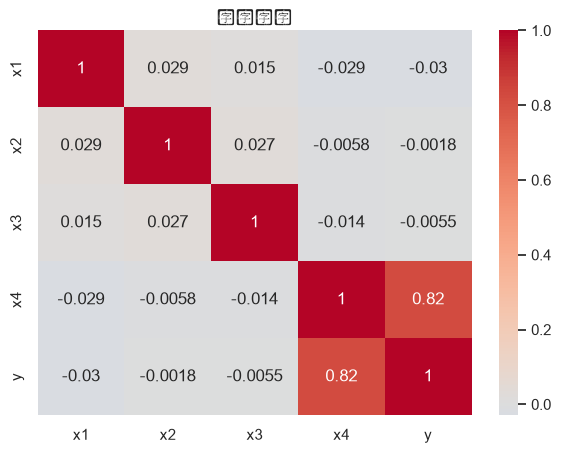

In [3]:
# 各列の基本統計量を表示する
# count: データ数、mean: 平均、std: 標準偏差、min/max: 最小値/最大値
display(df.describe().T)

# 相関係数ヒートマップ用の描画領域を作る
plt.figure(figsize=(7, 5))

# 数値列どうしの相関係数をヒートマップで表示する
# annot=Trueで数値を表示し、center=0で正負の相関を見やすくする
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0)

# グラフのタイトルを設定する
plt.title("相関係数")

# グラフを表示する
plt.show()

## 3. 2乗・3乗特徴量を作る

元の説明変数 `x1`〜`x4` に対して、以下のような特徴量を追加します。

- `x1_squared`, `x2_squared`, ...
- `x1_cubed`, `x2_cubed`, ...

ここでは交互作用項（例：`x1 * x2`）は作らず、ヒント通り各特徴量の 2乗・3乗を追加します。

In [4]:
# 説明変数として使う列を指定する
feature_cols = ["x1", "x2", "x3", "x4"]

# 予測したい目的変数の列を指定する
target_col = "y"


# 元の特徴量に2乗・3乗の特徴量を追加する関数を定義する
def add_power_features(data: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """各説明変数に対して2乗・3乗の特徴量を追加する。"""

    # 元の説明変数だけをコピーする
    # copy()を使うことで、元データdfを直接変更しないようにする
    X = data[cols].copy()

    # 各説明変数について、2乗と3乗の列を追加する
    for col in cols:
        # 例: x1 -> x1_squared
        X[f"{col}_squared"] = data[col] ** 2

        # 例: x1 -> x1_cubed
        X[f"{col}_cubed"] = data[col] ** 3

    # 2乗・3乗特徴量を追加したDataFrameを返す
    return X


# 比較用として、元の特徴量だけのデータを作る
X_base = df[feature_cols]

# Lasso回帰に使うため、2乗・3乗特徴量を追加したデータを作る
X_engineered = add_power_features(df, feature_cols)

# 目的変数yを取り出す
y = df[target_col]

# 作成した特徴量の先頭5行を表示する
display(X_engineered.head())

# 元の特徴量数を表示する
print("元の特徴量数:", X_base.shape[1])

# 特徴量エンジニアリング後の特徴量数を表示する
print("特徴量エンジニアリング後の特徴量数:", X_engineered.shape[1])

,x1,x2,x3,x4,x1_squared,x1_cubed,x2_squared,x2_cubed,x3_squared,x3_cubed,x4_squared,x4_cubed
0,-1.254599,-3.148671,-2.382943,1.727030,1.574018,-1.974761,9.914127,-31.216322,5.678418,-13.531348,2.982632,5.151095
1,4.507143,0.419009,-2.530212,2.966814,20.314339,91.559630,0.175569,0.073565,6.401973,-16.198348,8.801985,26.113853
2,2.319939,3.729458,4.062546,-2.495321,5.382119,12.486190,13.908860,51.872513,16.504278,67.049387,6.226627,-15.537433
3,0.986585,2.322249,-2.504538,1.248741,0.973350,0.960292,5.392840,12.523516,6.272711,-15.710242,1.559354,1.947229
4,-3.439814,3.065611,-2.280503,0.717460,11.832318,-40.700967,9.397974,28.810536,5.200693,-11.860194,0.514749,0.369311


元の特徴量数: 4
特徴量エンジニアリング後の特徴量数: 12


## 4. 学習データとテストデータに分割

In [5]:
# 元特徴量のみのデータを、学習用80%・テスト用20%に分ける
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

# 2乗・3乗特徴量を追加したデータも、同じ条件で学習用・テスト用に分ける
# yの分割結果は上と同じになるので、ここでは _ で受け取って使わない
X_train_eng, X_test_eng, _, _ = train_test_split(
    X_engineered,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

# 学習データの行数と特徴量数を表示する
print("学習データ:", X_train_eng.shape)

# テストデータの行数と特徴量数を表示する
print("テストデータ:", X_test_eng.shape)

学習データ: (800, 12)
テストデータ: (200, 12)


## 5. Lasso 回帰モデルを学習する

Lasso は特徴量のスケールに影響を受けやすいため、`StandardScaler` で標準化してから学習します。

`LassoCV` を使い、交差検証で正則化の強さ `alpha` を自動選択します。

In [6]:
# Lasso回帰モデルを学習する関数を定義する
def fit_lasso_model(X_train, y_train):
    # Pipelineで「標準化 -> LassoCV」を1つの流れにまとめる
    model = Pipeline([
        # Lassoは特徴量のスケールに影響を受けやすいため、先に標準化する
        ("scaler", StandardScaler()),

        # LassoCVは交差検証によって、正則化の強さalphaを自動で選ぶ
        # max_iterを大きめにして、収束しやすくしている
        ("lasso", LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=100_000)),
    ])

    # 学習データを使ってモデルを学習する
    model.fit(X_train, y_train)

    # 学習済みモデルを返す
    return model


# 元の特徴量のみでLasso回帰を学習する
base_model = fit_lasso_model(X_train_base, y_train)

# 2乗・3乗特徴量を追加したデータでLasso回帰を学習する
eng_model = fit_lasso_model(X_train_eng, y_train)

# 元特徴量のみのモデルで選ばれたalphaを表示する
print("元特徴量のみの best alpha:", base_model.named_steps["lasso"].alpha_)

# 2乗・3乗特徴量ありのモデルで選ばれたalphaを表示する
print("2乗・3乗特徴量ありの best alpha:", eng_model.named_steps["lasso"].alpha_)

元特徴量のみの best alpha: 0.22131366582952522
2乗・3乗特徴量ありの best alpha: 0.06045500282545656


## 6. 評価指標で比較する

In [7]:
# 回帰モデルの評価指標を計算する関数を定義する
def regression_metrics(model, X_test, y_test, label: str) -> dict:
    # テストデータに対する予測値を作る
    y_pred = model.predict(X_test)

    # 評価指標を辞書形式で返す
    return {
        # モデル名
        "model": label,

        # MAE: 予測誤差の絶対値の平均。小さいほど良い
        "MAE": mean_absolute_error(y_test, y_pred),

        # RMSE: 大きな誤差を重めに見る指標。小さいほど良い
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),

        # R2: 決定係数。1に近いほど良い
        "R2": r2_score(y_test, y_pred),
    }


# 2つのモデルの評価結果をDataFrameにまとめる
results = pd.DataFrame([
    # 元特徴量のみのモデルを評価する
    regression_metrics(base_model, X_test_base, y_test, "元特徴量のみ"),

    # 2乗・3乗特徴量ありのモデルを評価する
    regression_metrics(eng_model, X_test_eng, y_test, "2乗・3乗特徴量あり"),
])

# 評価結果を表として表示する
display(results)

,model,MAE,RMSE,R2
0,元特徴量のみ,4.905121,5.990065,0.662003
1,2乗・3乗特徴量あり,1.631827,2.058836,0.960070


/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv

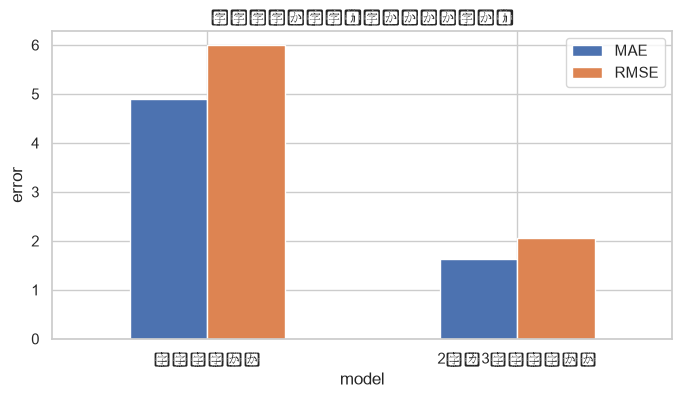

/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv

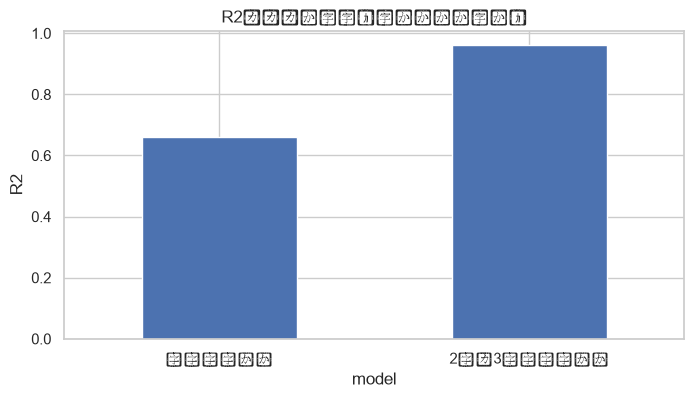

In [8]:
# MAEとRMSEを棒グラフで比較する
ax = results.set_index("model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(8, 4))

# グラフタイトルを設定する
ax.set_title("誤差指標の比較（小さいほど良い）")

# 縦軸のラベルを設定する
ax.set_ylabel("error")

# 横軸のモデル名を横向きにして読みやすくする
plt.xticks(rotation=0)

# グラフを表示する
plt.show()

# R2スコアを棒グラフで比較する
ax = results.set_index("model")[["R2"]].plot(kind="bar", figsize=(8, 4), legend=False)

# グラフタイトルを設定する
ax.set_title("R2スコアの比較（大きいほど良い）")

# 縦軸のラベルを設定する
ax.set_ylabel("R2")

# 横軸のモデル名を横向きにして読みやすくする
plt.xticks(rotation=0)

# グラフを表示する
plt.show()

## 7. 予測値と実測値を可視化する

/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv

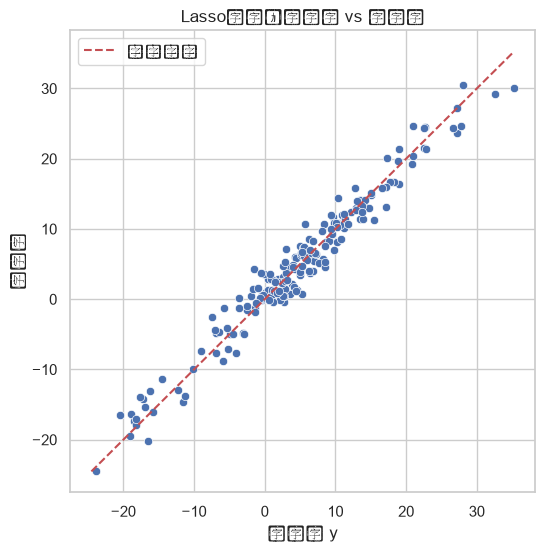

In [9]:
# 2乗・3乗特徴量ありのモデルで、テストデータの予測値を作る
y_pred_eng = eng_model.predict(X_test_eng)

# 予測値と実測値を比較する散布図の描画領域を作る
plt.figure(figsize=(6, 6))

# 横軸に実測値、縦軸に予測値を置いて散布図を描く
sns.scatterplot(x=y_test, y=y_pred_eng)

# 完全一致線を引くため、実測値と予測値を含めた最小値を求める
min_val = min(y_test.min(), y_pred_eng.min())

# 完全一致線を引くため、実測値と予測値を含めた最大値を求める
max_val = max(y_test.max(), y_pred_eng.max())

# 予測値と実測値が完全に一致する基準線を赤い破線で描く
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="完全一致")

# 横軸ラベルを設定する
plt.xlabel("実測値 y")

# 縦軸ラベルを設定する
plt.ylabel("予測値")

# グラフタイトルを設定する
plt.title("Lasso回帰：予測値 vs 実測値")

# 凡例を表示する
plt.legend()

# グラフを表示する
plt.show()

## 8. Lasso が選んだ特徴量を確認する

Lasso は重要でない特徴量の係数を 0 にします。どの特徴量が残ったかを確認します。

In [10]:
# Pipelineの中から、学習済みのLassoモデル部分を取り出す
lasso = eng_model.named_steps["lasso"]

# 特徴量名、係数、係数の絶対値をDataFrameにまとめる
coef_df = pd.DataFrame({
    # 特徴量名
    "feature": X_engineered.columns,

    # Lassoが学習した係数
    "coef": lasso.coef_,

    # 係数の大きさを比較しやすくするため、絶対値も作る
    "abs_coef": np.abs(lasso.coef_),
}).sort_values("abs_coef", ascending=False)

# 係数がほぼ0ではない特徴量だけを取り出す
# Lassoでは不要と判断された特徴量の係数が0になりやすい
nonzero_coef_df = coef_df[coef_df["coef"].abs() > 1e-10]

# 係数が0ではない特徴量の数を表示する
print("係数が0ではない特徴量数:", len(nonzero_coef_df), "/", len(coef_df))

# 係数が残った特徴量を表示する
display(nonzero_coef_df)

係数が0ではない特徴量数: 2 / 12


,feature,coef,abs_coef
11,x4_cubed,9.167352,9.167352
4,x1_squared,3.688570,3.688570


/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/４/.venv

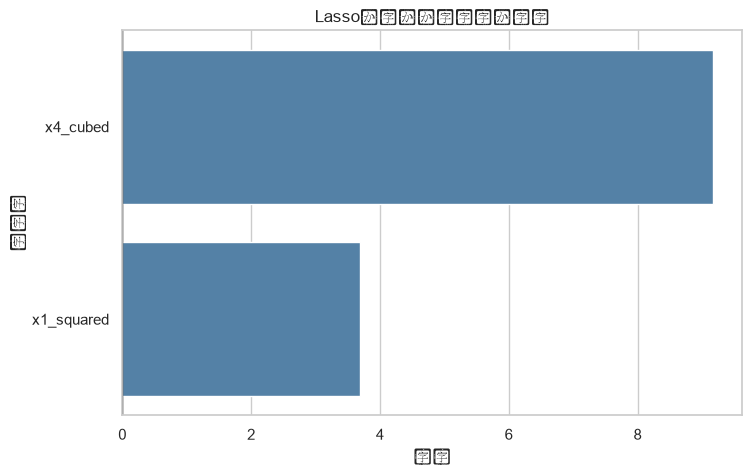

In [11]:
# 係数の棒グラフを描くための描画領域を作る
plt.figure(figsize=(8, 5))

# 係数が0ではない特徴量だけを棒グラフで表示する
sns.barplot(data=nonzero_coef_df, x="coef", y="feature", color="steelblue")

# 係数0の位置が分かるように、縦線を引く
plt.axvline(0, color="black", linewidth=1)

# グラフタイトルを設定する
plt.title("Lassoで残った特徴量の係数")

# 横軸ラベルを設定する
plt.xlabel("係数")

# 縦軸ラベルを設定する
plt.ylabel("特徴量")

# グラフを表示する
plt.show()

## 9. 結論

In [12]:
# R2が最も高いモデルを取り出す
best_row = results.sort_values("R2", ascending=False).iloc[0]

# 最も良かったモデル名を表示する
print(f"R2が高かったモデル: {best_row['model']}")

# 最も良かったモデルのR2を表示する
print(f"R2: {best_row['R2']:.4f}")

# 最も良かったモデルのRMSEを表示する
print(f"RMSE: {best_row['RMSE']:.4f}")

# まとめの見出しを表示する
print("\n今回のポイント:")

# 今回行った特徴量エンジニアリングの内容を表示する
print("- 元の特徴量に2乗・3乗特徴量を追加した")

# LassoCVでalphaを選んだことを表示する
print("- LassoCVでalphaを自動選択した")

# Lassoの特徴量選択の効果を表示する
print("- Lassoにより、重要度の低い特徴量は係数が0になった")

R2が高かったモデル: 2乗・3乗特徴量あり
R2: 0.9601
RMSE: 2.0588

今回のポイント:
- 元の特徴量に2乗・3乗特徴量を追加した
- LassoCVでalphaを自動選択した
- Lassoにより、重要度の低い特徴量は係数が0になった
